### Description
### Given the medical report of the person, develope  model to predict whether person will have Heart diesease or not
* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thalium: 0 = normal; 1 = fixed defect; 2 = reversable defect

In [2]:
import pandas as pd

In [3]:
data = pd.read_csv("Heart.csv")

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    int64  
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    object 
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    object 
 14  AHD         303 non-null    object 
dtypes: float64(2), int64(10), object(3)
memory usage: 35.6+ KB


In [5]:
data[data['Ca'].isna() | data['Thal'].isna()]

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
87,88,53,0,nonanginal,128,216,0,2,115,0,0.0,1,0.0,NaN,No
166,167,52,1,nonanginal,138,223,0,0,169,0,0.0,1,NaN,normal,No
192,193,43,1,asymptomatic,132,247,1,2,143,1,0.1,2,NaN,reversable,Yes
266,267,52,1,asymptomatic,128,204,1,0,156,1,1.0,2,0.0,NaN,Yes
287,288,58,1,nontypical,125,220,0,0,144,0,0.4,2,NaN,reversable,No
302,303,38,1,nonanginal,138,175,0,0,173,0,0.0,1,NaN,normal,No


In [6]:
data['Ca'].value_counts()

Ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64

In [7]:
data.dropna(inplace=True)

In [8]:
data.shape

(297, 15)

In [9]:
data.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [10]:
import matplotlib.pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x2045d3a2b70>,
 'caps': [<matplotlib.lines.Line2D at 0x2045d3a31d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2045d2e0380>],
 'medians': [<matplotlib.lines.Line2D at 0x2045d3a3800>],
 'fliers': [<matplotlib.lines.Line2D at 0x2045d3a3b00>],
 'means': []}

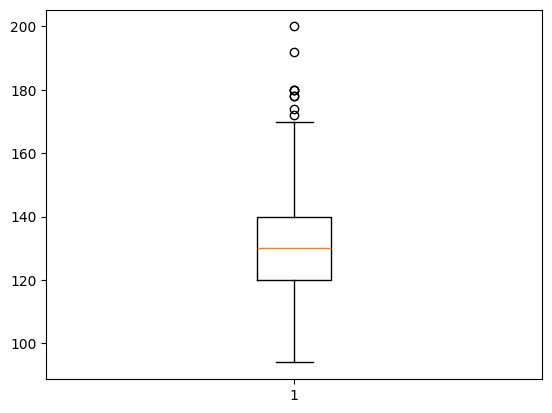

In [11]:
plt.boxplot(data["RestBP"])

In [12]:
import seaborn as sns

In [13]:
def checkOutlier(data, col):
    plt.subplot(1,2,1)
    plt.boxplot(data[col])
    plt.subplot(1,2,2)
    sns.histplot(data=data, x=col,kde=True)
    plt.axvline(data[col].mean()+(3*data[col].std()),color='red')
    plt.axvline(data[col].mean()-(3*data[col].std()),color='red')

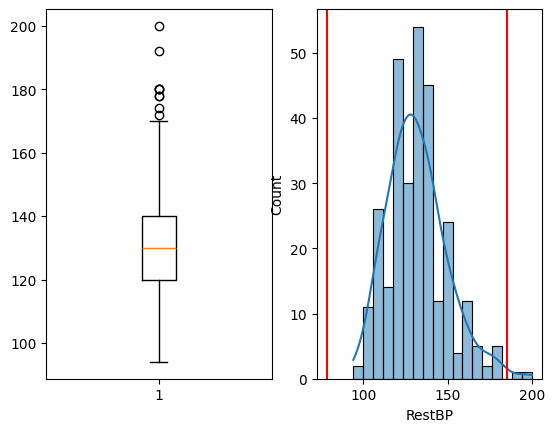

In [14]:
checkOutlier(data,'RestBP')

In [15]:
def handleOutliers(data, col):
    q3 = data[col].quantile(0.75)
    q1 = data[col].quantile(0.25)
    iqr = q3-q1
    upper = q3 + (1.5*iqr)
    lower =q1 - (1.5*iqr)
    data.loc[data[col]>upper,col ] = upper 
    data.loc[data[col]<lower,col ] = lower 

In [16]:
handleOutliers(data,'RestBP')

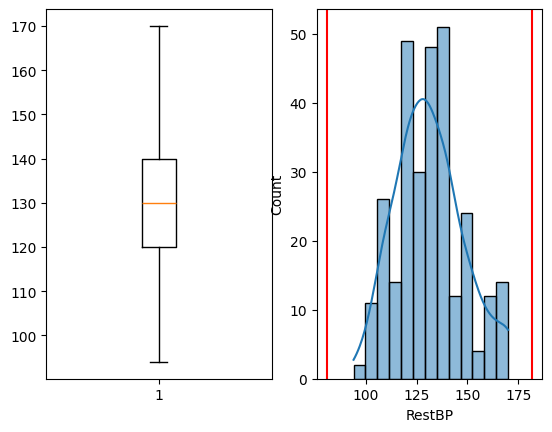

In [17]:
checkOutlier(data,'RestBP')

In [18]:
data['ChestPain'].unique()

array(['typical', 'asymptomatic', 'nonanginal', 'nontypical'],
      dtype=object)

In [19]:
data['ChestPain']=data['ChestPain'].replace({'typical':0, 'asymptomatic':1, 'nonanginal':2, 'nontypical':3})

C:\Users\Dipak\AppData\Local\Temp\ipykernel_3160\1678587424.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['ChestPain']=data['ChestPain'].replace({'typical':0, 'asymptomatic':1, 'nonanginal':2, 'nontypical':3})


In [20]:
data['Thal'].unique()

array(['fixed', 'normal', 'reversable'], dtype=object)

In [21]:
data['Thal'] = data['Thal'].replace({'fixed':0, 'normal':1, 'reversable':2})

C:\Users\Dipak\AppData\Local\Temp\ipykernel_3160\3362236960.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Thal'] = data['Thal'].replace({'fixed':0, 'normal':1, 'reversable':2})


In [22]:
data.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,0,145,233,1,2,150,0,2.3,3,0.0,0,No
1,2,67,1,1,160,286,0,2,108,1,1.5,2,3.0,1,Yes
2,3,67,1,1,120,229,0,2,129,1,2.6,2,2.0,2,Yes
3,4,37,1,2,130,250,0,0,187,0,3.5,3,0.0,1,No
4,5,41,0,3,130,204,0,2,172,0,1.4,1,0.0,1,No


In [23]:
data.describe()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,150.673401,54.542088,0.676768,1.531987,131.343434,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,1.326599
std,87.323283,9.049736,0.468500,0.858082,16.801401,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.585061
min,1.000000,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,75.000000,48.000000,0.000000,1.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,150.000000,56.000000,1.000000,1.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,1.000000
75%,226.000000,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,2.000000
max,302.000000,77.000000,1.000000,3.000000,170.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,2.000000


In [24]:
X = data.drop(["Unnamed: 0","AHD"],axis=1)
y = data['AHD']

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
ss = StandardScaler()
X_trans = ss.fit_transform(X)

In [27]:
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X_trans,y,test_size=0.3,random_state=42)

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

In [29]:
rf = RandomForestClassifier()
result = cross_validate(rf,X_train,y_train)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
result['test_score'].mean()

np.float64(0.79732868757259)

In [31]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

test_pred = rf.predict(X_test)
accuracy_score(y_test,test_pred)

0.8888888888888888

In [43]:
train_pred = rf.predict(X_train)
accuracy_score(y_train,train_pred)

1.0

In [32]:
confusion_matrix(y_test,test_pred)

array([[45,  4],
       [ 6, 35]])

In [33]:
print(classification_report(y_test, test_pred))

              precision    recall  f1-score   support

          No       0.88      0.92      0.90        49
         Yes       0.90      0.85      0.88        41

    accuracy                           0.89        90
   macro avg       0.89      0.89      0.89        90
weighted avg       0.89      0.89      0.89        90



In [39]:
data.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,0,145,233,1,2,150,0,2.3,3,0.0,0,No
1,2,67,1,1,160,286,0,2,108,1,1.5,2,3.0,1,Yes
2,3,67,1,1,120,229,0,2,129,1,2.6,2,2.0,2,Yes
3,4,37,1,2,130,250,0,0,187,0,3.5,3,0.0,1,No
4,5,41,0,3,130,204,0,2,172,0,1.4,1,0.0,1,No


In [42]:
age = 34
dict1 = {'fixed':0, 'normal':1, 'reversable':2}
thal="normal"
sex = 0
restBp = 130
thal = dict1[thal]
input_trans = ss.transform([[age,thal,sex,restBp]])

C:\Users\Dipak\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


ValueError: X has 4 features, but StandardScaler is expecting 13 features as input.